# Train Threshold Typology Classifier

This notebook trains a supervised classifier using a pretrained MAE encoder.

**Pipeline:**
- Load pretrained MAE encoder
- Add MLP classification head
- Fine-tune on labeled synthetic data (t1-t8)
- Evaluate with comprehensive metrics

## Setup

In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam, AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from config_classifier import get_classifier_config
from classifier_model import ThresholdClassifier
from dataset_classifier import create_classifier_dataloaders

from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    precision_recall_fscore_support, top_k_accuracy_score
)

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print(f"Device: {device}")

PyTorch version: 2.10.0.dev20251029+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 5060 Laptop GPU
Device: cuda


## Configuration

In [2]:
# Data path
DATA_ROOT = r"C:\Users\shrua\OneDrive\Desktop\threshold project\threshold\data"

# Choose training strategy
FREEZE_ENCODER = True  # True = frozen encoder, False = fine-tune encoder

# Get config
config = get_classifier_config(freeze_encoder=FREEZE_ENCODER)

# Typology names
TYPOLOGY_NAMES = ['t1', 't2', 't3', 't4', 't5', 't6', 't7', 't8']

print(f"\nTraining mode: {'Frozen Encoder (Linear Probing)' if FREEZE_ENCODER else 'Fine-tuning Encoder'}")

Classifier Configuration:
  Pretrained encoder: ../models_MAE/output_mae_adjusted/encoder_mae_pretrained.pt
  Freeze encoder: True
  MLP architecture: 384 → 128 → 8
  Learning rate: 0.001
  Batch size: 32
  Epochs: 20
  Train/Val/Test split: 70%/15%/15%
  Output: ../output_classifier

Training mode: Frozen Encoder (Linear Probing)


## Load Data

In [3]:
train_loader, val_loader, test_loader, full_dataset, train_indices, val_indices, test_indices = create_classifier_dataloaders(
    data_root=DATA_ROOT,
    batch_size=config.batch_size,
    train_split=config.train_split,
    val_split=config.val_split,
    num_workers=4
)

print(f"\nData loaded successfully!")

Loaded 8046 threshold sequences from 32 files
Dataset split:
  Total samples: 8046
  Train: 5632 (70%)
  Val:   1206 (15%)
  Test:  1208 (15%)

Label distribution:
  Train:
    t1: 715 samples
    t2: 693 samples
    t3: 779 samples
    t4: 593 samples
    t5: 698 samples
    t6: 716 samples
    t7: 800 samples
    t8: 638 samples
  Val:
    t1: 148 samples
    t2: 147 samples
    t3: 162 samples
    t4: 131 samples
    t5: 137 samples
    t6: 163 samples
    t7: 170 samples
    t8: 148 samples
  Test:
    t1: 163 samples
    t2: 167 samples
    t3: 132 samples
    t4: 122 samples
    t5: 152 samples
    t6: 172 samples
    t7: 176 samples
    t8: 124 samples

Dataloaders created:
  Train batches: 176
  Val batches:   38
  Test batches:  38

Data loaded successfully!


## Create Model

In [4]:
# Create classifier
model = ThresholdClassifier(config)
model = model.to(device)

# Print parameter counts
params = model.get_num_params()
print(f"\nModel parameters:")
print(f"  Total:     {params['total']:,}")
print(f"  Trainable: {params['trainable']:,}")
print(f"  Frozen:    {params['frozen']:,}")
print(f"  Trainable %: {params['trainable']/params['total']*100:.1f}%")

Loading pretrained encoder from: ../models_MAE/output_mae_adjusted/encoder_mae_pretrained.pt
MAE Configuration:
  Image: 32×64, 1 channel(s)
  Patch size: 8×8
  Patches per frame: 32 (4×8)
  Total frames: 7
  Total patches: 224
  Masking strategy: ASYMMETRIC
    Frames 0-1 (before): 90% masked
    Frames 2-4 (at threshold): 50% masked
    Frames 5-6 (after): 90% masked
  Average mask ratio: 72.9%
  Encoder: 6 layers, dim=384
  Decoder: 4 layers, dim=192
✓ Encoder frozen (linear probing mode)
✓ MLP Head: 384 → 128 → 8

Model parameters:
  Total:     12,647,112
  Trainable: 1,842,696
  Frozen:    10,804,416
  Trainable %: 14.6%


## Setup Training

In [5]:
# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = AdamW(
    model.parameters(),
    lr=config.learning_rate,
    weight_decay=config.weight_decay
)

# Learning rate scheduler
scheduler = ReduceLROnPlateau(
    optimizer,
    mode='max',  # Maximize validation accuracy
    factor=config.scheduler_factor,
    patience=config.scheduler_patience
)

# Training state
best_val_acc = 0.0
train_losses = []
train_accs = []
val_losses = []
val_accs = []
epochs_no_improve = 0

print(f"Optimizer: AdamW (lr={config.learning_rate}, wd={config.weight_decay})")
print(f"Scheduler: ReduceLROnPlateau (patience={config.scheduler_patience})")
print(f"Early stopping: {config.early_stopping_patience} epochs")

Optimizer: AdamW (lr=0.001, wd=0.0001)
Scheduler: ReduceLROnPlateau (patience=10)
Early stopping: 20 epochs


## Training Loop

In [ ]:
print("="*80)
print("TRAINING")
print("="*80)
print()

for epoch in range(config.num_epochs):
    # ============ Training ============
    model.train()
    train_loss_epoch = 0.0
    train_correct = 0
    train_total = 0
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{config.num_epochs} [Train]")
    for batch in pbar:
        imgs = batch['frames'].to(device)  # [B, 7, 1, 32, 64]
        labels = batch['typology_label'].to(device)  # [B]
        
        # Forward
        logits = model(imgs)
        loss = criterion(logits, labels)
        
        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Metrics
        train_loss_epoch += loss.item() * imgs.size(0)
        _, predicted = logits.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()
        
        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc': f'{100.*train_correct/train_total:.2f}%'
        })
    
    train_loss_epoch /= train_total
    train_acc_epoch = 100. * train_correct / train_total
    train_losses.append(train_loss_epoch)
    train_accs.append(train_acc_epoch)
    
    # ============ Validation ============
    model.eval()
    val_loss_epoch = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{config.num_epochs} [Val]")
        for batch in pbar:
            imgs = batch['frames'].to(device)
            labels = batch['typology_label'].to(device)
            
            logits = model(imgs)
            loss = criterion(logits, labels)
            
            val_loss_epoch += loss.item() * imgs.size(0)
            _, predicted = logits.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
            
            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'acc': f'{100.*val_correct/val_total:.2f}%'
            })
    
    val_loss_epoch /= val_total
    val_acc_epoch = 100. * val_correct / val_total
    val_losses.append(val_loss_epoch)
    val_accs.append(val_acc_epoch)
    
    # Update learning rate
    scheduler.step(val_acc_epoch)
    current_lr = optimizer.param_groups[0]['lr']
    
    # Print epoch summary
    print(f"Epoch {epoch+1}/{config.num_epochs}:")
    print(f"  Train Loss: {train_loss_epoch:.4f}, Train Acc: {train_acc_epoch:.2f}%")
    print(f"  Val Loss:   {val_loss_epoch:.4f}, Val Acc:   {val_acc_epoch:.2f}%")
    print(f"  LR: {current_lr:.2e}")
    
    # Save best model
    if val_acc_epoch > best_val_acc:
        best_val_acc = val_acc_epoch
        epochs_no_improve = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc_epoch,
            'val_loss': val_loss_epoch,
            'config': config,
        }, os.path.join(config.checkpoint_dir, 'classifier_best.pt'))
        print(f"  → Best model saved! (val_acc: {val_acc_epoch:.2f}%)")
    else:
        epochs_no_improve += 1
    
    # Early stopping
    if epochs_no_improve >= config.early_stopping_patience:
        print(f"\nEarly stopping triggered after {epoch+1} epochs")
        break
    
    print()

print("="*80)
print("TRAINING COMPLETE!")
print("="*80)
print(f"Best validation accuracy: {best_val_acc:.2f}%")

TRAINING



Epoch 1/20 [Train]:   0%|          | 0/176 [00:08<?, ?it/s]

Epoch 1/20 [Val]:   0%|          | 0/38 [00:13<?, ?it/s]

Epoch 1/20:
  Train Loss: 0.7977, Train Acc: 78.69%
  Val Loss:   0.2779, Val Acc:   93.86%
  LR: 1.00e-03
  → Best model saved! (val_acc: 93.86%)



Epoch 2/20 [Train]:   0%|          | 0/176 [00:16<?, ?it/s]

...

Epoch 14/20 [Train]:   0%|          | 0/176 [00:25<?, ?it/s]

Epoch 14/20 [Val]:   0%|          | 0/38 [00:22<?, ?it/s]

Epoch 14/20:
  Train Loss: 0.0356, Train Acc: 98.93%
  Val Loss:   0.0192, Val Acc:   99.75%
  LR: 1.00e-03



Epoch 15/20 [Train]:   0%|          | 0/176 [00:22<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x00000293211D3880>
Traceback (most recent call last):
  File "c:\Users\shrua\anaconda3\envs\threshold\lib\site-packages\torch\utils\data\dataloader.py", line 1689, in __del__
    self._shutdown_workers()
  File "c:\Users\shrua\anaconda3\envs\threshold\lib\site-packages\torch\utils\data\dataloader.py", line 1653, in _shutdown_workers
    w.join(timeout=_utils.MP_STATUS_CHECK_INTERVAL)
  File "c:\Users\shrua\anaconda3\envs\threshold\lib\multiprocessing\process.py", line 149, in join
    res = self._popen.wait(timeout)
  File "c:\Users\shrua\anaconda3\envs\threshold\lib\multiprocessing\popen_spawn_win32.py", line 108, in wait
    res = _winapi.WaitForSingleObject(int(self._handle), msecs)
KeyboardInterrupt: 


## Visualize Training Curves

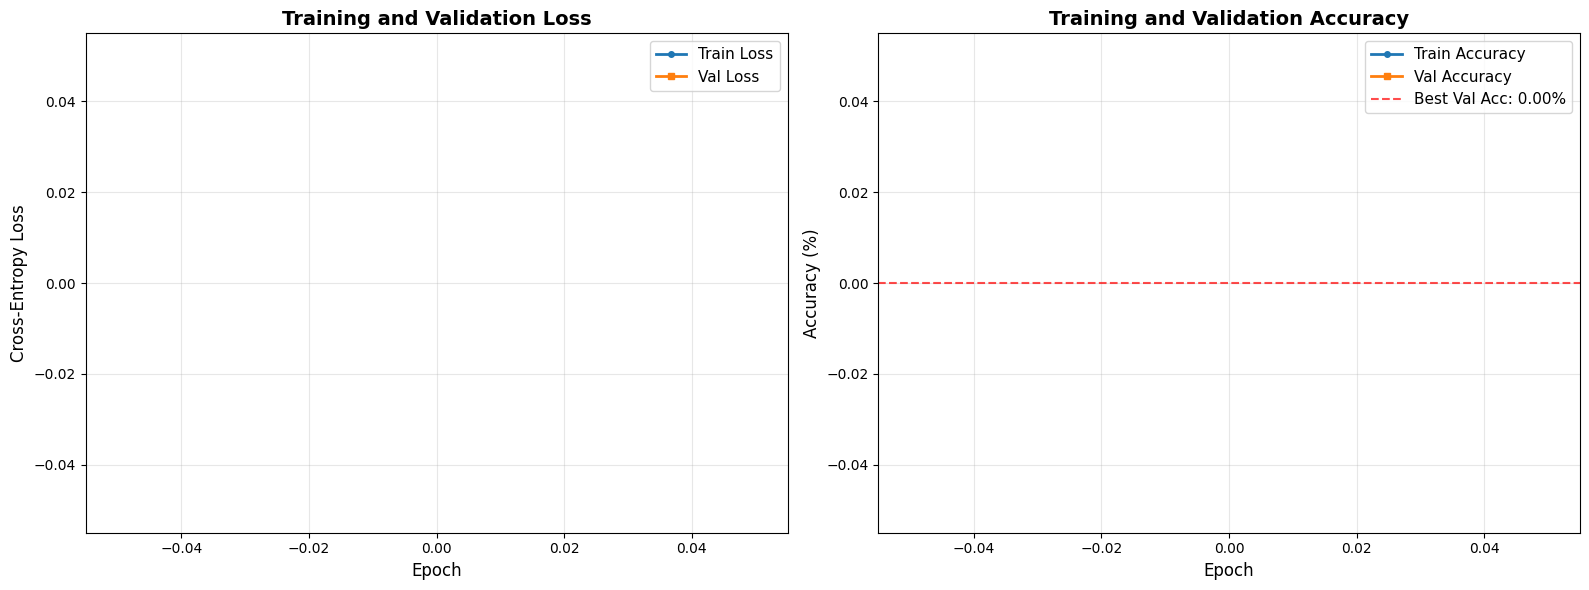

Training curves saved to: ../output_classifier/visualizations\training_curves.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

epochs_range = np.arange(1, len(train_losses) + 1)

# Loss plot
ax = axes[0]
ax.plot(epochs_range, train_losses, label='Train Loss', linewidth=2, marker='o', markersize=4)
ax.plot(epochs_range, val_losses, label='Val Loss', linewidth=2, marker='s', markersize=4)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Cross-Entropy Loss', fontsize=12)
ax.set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Accuracy plot
ax = axes[1]
ax.plot(epochs_range, train_accs, label='Train Accuracy', linewidth=2, marker='o', markersize=4)
ax.plot(epochs_range, val_accs, label='Val Accuracy', linewidth=2, marker='s', markersize=4)
ax.axhline(y=best_val_acc, color='r', linestyle='--', label=f'Best Val Acc: {best_val_acc:.2f}%', alpha=0.7)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(config.vis_dir, 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"Training curves saved to: {os.path.join(config.vis_dir, 'training_curves.png')}")

## Test Set Evaluation

In [8]:
print("="*80)
print("TEST SET EVALUATION")
print("="*80)
print()

# Load best model
checkpoint = torch.load(os.path.join(config.checkpoint_dir, 'classifier_best.pt'), weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {checkpoint['epoch']+1}")
print(f"Best val accuracy: {checkpoint['val_acc']:.2f}%")
print()

# Collect predictions
all_labels = []
all_preds = []
all_probs = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Evaluating test set"):
        imgs = batch['frames'].to(device)
        labels = batch['typology_label'].to(device)
        
        logits = model(imgs)
        probs = torch.softmax(logits, dim=1)
        _, preds = logits.max(1)
        
        all_labels.append(labels.cpu().numpy())
        all_preds.append(preds.cpu().numpy())
        all_probs.append(probs.cpu().numpy())

all_labels = np.concatenate(all_labels)
all_preds = np.concatenate(all_preds)
all_probs = np.concatenate(all_probs)

print(f"Test set size: {len(all_labels)} samples")
print()

TEST SET EVALUATION

Loaded best model from epoch 13
Best val accuracy: 99.92%



Evaluating test set:   0%|          | 0/38 [01:08<?, ?it/s]

Test set size: 1208 samples



## Overall Accuracy

In [9]:
# Overall accuracy
test_acc = accuracy_score(all_labels, all_preds)

print("="*80)
print("OVERALL ACCURACY")
print("="*80)
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print()

if test_acc > 0.8:
    print("✓ EXCELLENT! Accuracy > 80%")
elif test_acc > 0.7:
    print("✓ GOOD! Accuracy > 70%")
elif test_acc > 0.5:
    print("~ MODERATE. Accuracy > 50%")
else:
    print("✗ WEAK. Need improvement.")
print("="*80)
print()

OVERALL ACCURACY
Test Accuracy: 0.9975 (99.75%)

✓ EXCELLENT! Accuracy > 80%



## Per-Class Metrics

In [10]:
print("="*80)
print("PER-CLASS ACCURACY")
print("="*80)
print()

per_class_acc = {}
for i, typology in enumerate(TYPOLOGY_NAMES):
    mask = all_labels == i
    if mask.sum() > 0:
        class_acc = (all_preds[mask] == i).sum() / mask.sum()
        per_class_acc[typology] = class_acc
        print(f"  {typology}: {class_acc:.4f} ({class_acc*100:.2f}%) [{mask.sum()} samples]")
    else:
        per_class_acc[typology] = 0.0
        print(f"  {typology}: N/A (no samples)")

print()
print("="*80)
print()

PER-CLASS ACCURACY

  t1: 1.0000 (100.00%) [163 samples]
  t2: 1.0000 (100.00%) [167 samples]
  t3: 0.9924 (99.24%) [132 samples]
  t4: 1.0000 (100.00%) [122 samples]
  t5: 0.9934 (99.34%) [152 samples]
  t6: 0.9942 (99.42%) [172 samples]
  t7: 1.0000 (100.00%) [176 samples]
  t8: 1.0000 (100.00%) [124 samples]




## Confusion Matrix

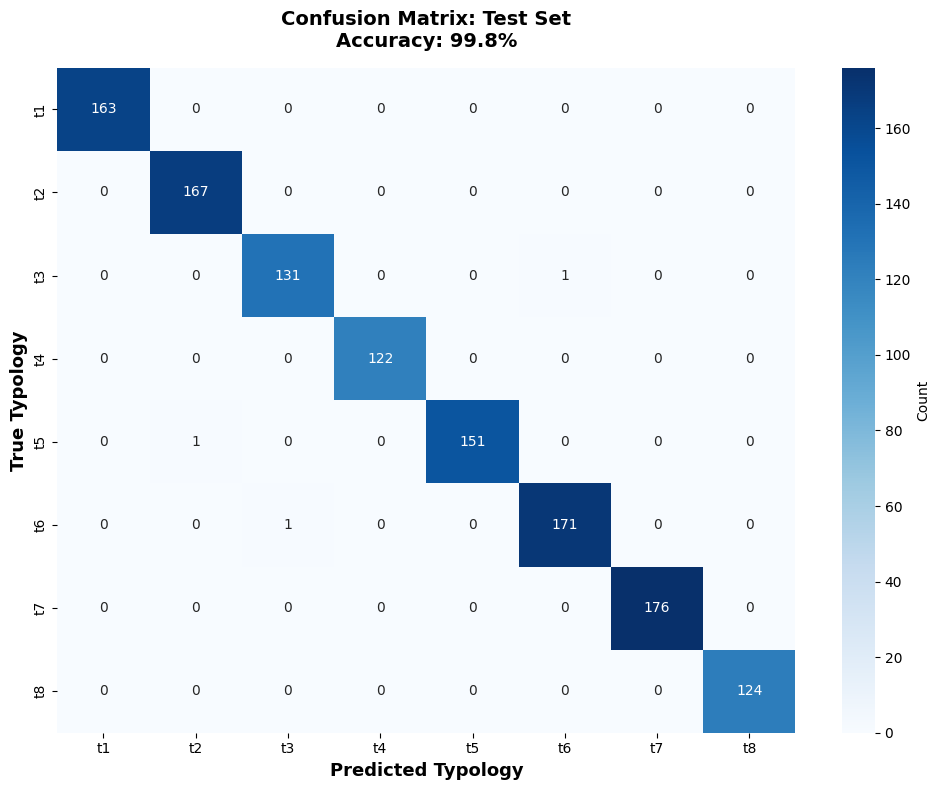

Confusion matrix saved to: ../output_classifier/visualizations\confusion_matrix.png


In [11]:
# Compute confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Plot
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=TYPOLOGY_NAMES,
    yticklabels=TYPOLOGY_NAMES,
    cbar_kws={'label': 'Count'},
    ax=ax
)

ax.set_xlabel('Predicted Typology', fontsize=13, fontweight='bold')
ax.set_ylabel('True Typology', fontsize=13, fontweight='bold')
ax.set_title(
    f'Confusion Matrix: Test Set\nAccuracy: {test_acc:.1%}',
    fontsize=14,
    fontweight='bold',
    pad=15
)

plt.tight_layout()
plt.savefig(os.path.join(config.vis_dir, 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"Confusion matrix saved to: {os.path.join(config.vis_dir, 'confusion_matrix.png')}")

## Classification Report

In [12]:
print("="*80)
print("CLASSIFICATION REPORT")
print("="*80)
print()

report = classification_report(
    all_labels,
    all_preds,
    target_names=TYPOLOGY_NAMES,
    digits=3
)

print(report)

# Save to file
with open(os.path.join(config.output_dir, 'classification_report.txt'), 'w') as f:
    f.write("CLASSIFICATION REPORT\n")
    f.write("="*80 + "\n\n")
    f.write(report)
    f.write("\n\nTest Accuracy: {:.4f}\n".format(test_acc))

print(f"\nReport saved to: {os.path.join(config.output_dir, 'classification_report.txt')}")

CLASSIFICATION REPORT

              precision    recall  f1-score   support

          t1      1.000     1.000     1.000       163
          t2      0.994     1.000     0.997       167
          t3      0.992     0.992     0.992       132
          t4      1.000     1.000     1.000       122
          t5      1.000     0.993     0.997       152
          t6      0.994     0.994     0.994       172
          t7      1.000     1.000     1.000       176
          t8      1.000     1.000     1.000       124

    accuracy                          0.998      1208
   macro avg      0.998     0.998     0.998      1208
weighted avg      0.998     0.998     0.998      1208


Report saved to: ../output_classifier\classification_report.txt


## Top-K Accuracy

In [13]:
print("="*80)
print("TOP-K ACCURACY")
print("="*80)
print()

for k in [1, 2, 3]:
    topk_acc = top_k_accuracy_score(all_labels, all_probs, k=k)
    print(f"Top-{k} Accuracy: {topk_acc:.4f} ({topk_acc*100:.2f}%)")

print()
print("Interpretation:")
print("  - Top-1: Exact prediction is correct")
print("  - Top-2: Correct label in top 2 predictions")
print("  - Top-3: Correct label in top 3 predictions")
print("="*80)
print()

TOP-K ACCURACY

Top-1 Accuracy: 0.9975 (99.75%)
Top-2 Accuracy: 0.9992 (99.92%)
Top-3 Accuracy: 0.9992 (99.92%)

Interpretation:
  - Top-1: Exact prediction is correct
  - Top-2: Correct label in top 2 predictions
  - Top-3: Correct label in top 3 predictions



## Confidence Analysis

In [14]:
print("="*80)
print("CONFIDENCE ANALYSIS")
print("="*80)
print()

# Get confidence (max probability)
confidences = all_probs.max(axis=1)

# Separate correct and incorrect predictions
correct_mask = all_preds == all_labels
incorrect_mask = ~correct_mask

conf_correct = confidences[correct_mask]
conf_incorrect = confidences[incorrect_mask]

print(f"Average confidence (correct predictions):   {conf_correct.mean():.4f}")
print(f"Average confidence (incorrect predictions): {conf_incorrect.mean():.4f}")
print()

# Find high-confidence errors
high_conf_threshold = 0.8
high_conf_errors = incorrect_mask & (confidences > high_conf_threshold)

print(f"High-confidence errors (confidence > {high_conf_threshold}):")
print(f"  Count: {high_conf_errors.sum()} / {len(all_labels)} ({high_conf_errors.sum()/len(all_labels)*100:.2f}%)")

if high_conf_errors.sum() > 0:
    print(f"\n  Examples:")
    error_indices = np.where(high_conf_errors)[0][:5]  # Show first 5
    for idx in error_indices:
        true_label = TYPOLOGY_NAMES[all_labels[idx]]
        pred_label = TYPOLOGY_NAMES[all_preds[idx]]
        conf = confidences[idx]
        print(f"    Sample #{idx}: True={true_label}, Pred={pred_label}, Conf={conf:.3f}")

print()
print("="*80)
print()

CONFIDENCE ANALYSIS

Average confidence (correct predictions):   0.9885
Average confidence (incorrect predictions): 0.6973

High-confidence errors (confidence > 0.8):
  Count: 1 / 1208 (0.08%)

  Examples:
    Sample #709: True=t5, Pred=t2, Conf=0.863




## Per-Class Performance Visualization

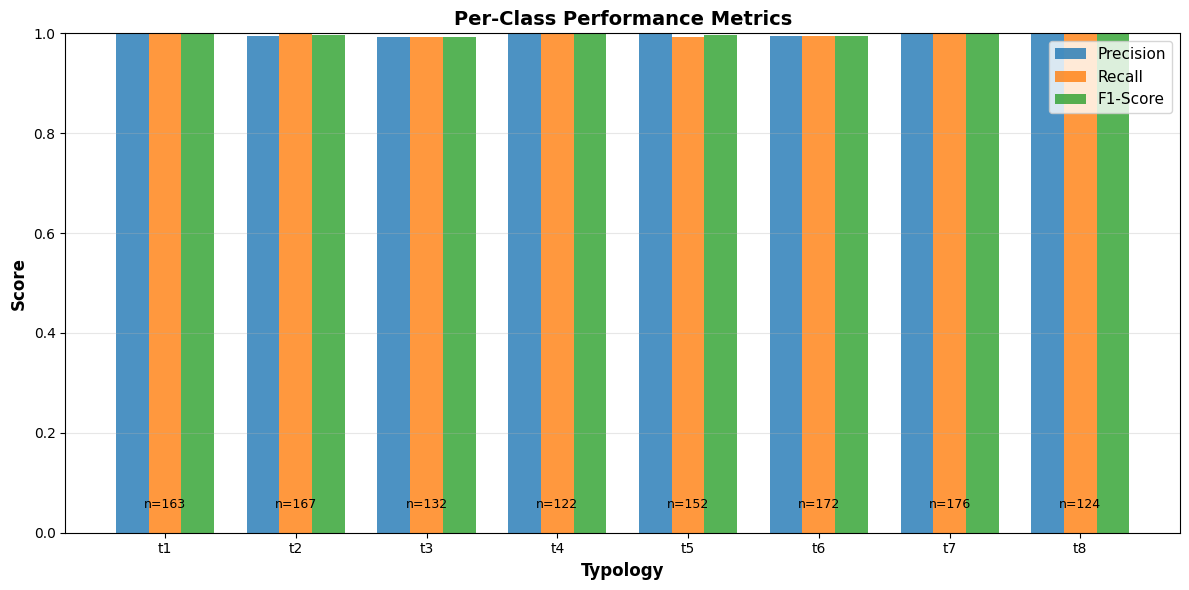

Per-class metrics saved to: ../output_classifier/visualizations\per_class_metrics.png


In [15]:
# Get precision, recall, f1 per class
precision, recall, f1, support = precision_recall_fscore_support(
    all_labels, all_preds, average=None
)

# Plot
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

x = np.arange(len(TYPOLOGY_NAMES))
width = 0.25

ax.bar(x - width, precision, width, label='Precision', alpha=0.8)
ax.bar(x, recall, width, label='Recall', alpha=0.8)
ax.bar(x + width, f1, width, label='F1-Score', alpha=0.8)

ax.set_xlabel('Typology', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Per-Class Performance Metrics', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(TYPOLOGY_NAMES)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0, 1.0])

# Add support counts as text
for i, (typ, sup) in enumerate(zip(TYPOLOGY_NAMES, support)):
    ax.text(i, 0.05, f'n={sup}', ha='center', fontsize=9, color='black')

plt.tight_layout()
plt.savefig(os.path.join(config.vis_dir, 'per_class_metrics.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"Per-class metrics saved to: {os.path.join(config.vis_dir, 'per_class_metrics.png')}")

## Final Summary

In [16]:
print("="*80)
print("FINAL SUMMARY")
print("="*80)
print()
print(f"Training mode: {'Frozen Encoder' if FREEZE_ENCODER else 'Fine-tuned Encoder'}")
print(f"Epochs trained: {len(train_losses)}")
print(f"Best val accuracy: {best_val_acc:.2f}%")
print(f"Test accuracy: {test_acc*100:.2f}%")
print()
print("Model architecture:")
print(f"  Encoder: Pretrained TimeSformer MAE")
print(f"  MLP Head: {config.encoder_dim} → {config.mlp_hidden_dim} → {config.num_classes}")
print(f"  Trainable params: {params['trainable']:,}")
print()
print("Output files:")
print(f"  Best model: {os.path.join(config.checkpoint_dir, 'classifier_best.pt')}")
print(f"  Training curves: {os.path.join(config.vis_dir, 'training_curves.png')}")
print(f"  Confusion matrix: {os.path.join(config.vis_dir, 'confusion_matrix.png')}")
print(f"  Classification report: {os.path.join(config.output_dir, 'classification_report.txt')}")
print()
print("Next steps:")
print("  1. Use predict_buildings.ipynb to classify real buildings")
print("  2. Compare frozen vs fine-tuned performance if needed")
print("="*80)

FINAL SUMMARY

Training mode: Frozen Encoder
Epochs trained: 0
Best val accuracy: 0.00%
Test accuracy: 99.75%

Model architecture:
  Encoder: Pretrained TimeSformer MAE
  MLP Head: 384 → 128 → 8
  Trainable params: 1,842,696

Output files:
  Best model: ../output_classifier/checkpoints\classifier_best.pt
  Training curves: ../output_classifier/visualizations\training_curves.png
  Confusion matrix: ../output_classifier/visualizations\confusion_matrix.png
  Classification report: ../output_classifier\classification_report.txt

Next steps:
  1. Use predict_buildings.ipynb to classify real buildings
  2. Compare frozen vs fine-tuned performance if needed
